# GBLUP Lab — Results at a Glance

Five charts, one per phase's most interesting finding. Full narrative:
[`README.md`](README.md). Full detail per phase: [`RESULTS_PHASE0.md`]
(RESULTS_PHASE0.md)–[`RESULTS_PHASE4.md`](RESULTS_PHASE4.md). Plan and
rationale: [`LAB_PLAN.md`](LAB_PLAN.md).

This lab builds on **MPDOK** (Fraser's hand-built CUDA Fortran/CuPy
GMRES-IR/LU-IR solver — GitHub link to be added here). MPDOK's own `gblup/`
lab already proved exact genomic BLUP beats the breeding industry's standard
APY approximation, with a real economic argument (an 85.6% collapse in
selection intensity at the elite tail that whole-population accuracy hides).
This lab adds what MPDOK's didn't have: marginal-likelihood-fit
hyperparameters, nonlinear/RKHS kernels, and calibrated uncertainty (NLL) —
applied to MPDOK's own data, read in place.

**The throughline across all five charts:** every surprising number was
checked against something external — a second engine, a primary paper read
directly, a coverage check — before being trusted. Two of the five checks
caught a real problem a clean exit code would have hidden.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- lab viz conventions (matches gp_lab/build_results_nb.py) -----------
INK, INK2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e5e4e0", "#fcfcfb"
C_BLUE, C_AQUA, C_YELLOW = "#2a78d6", "#1baf7a", "#eda100"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2,
    "axes.edgecolor": GRID, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11, "figure.dpi": 110,
})

def bar_labels(ax, bars, fmt="{:.3f}", dy=0.01):
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width() / 2, h + dy, fmt.format(h),
                ha="center", va="bottom", fontsize=9, color=INK)


## 1. Phase 0 — a documentation-drift bug, caught by cross-engine reproduction

MPDOK's own `README.md` reports wheat/mice GBLUP accuracy numbers. Running
MPDOK's *actual, current* `cv_lambda_sweep` function (not the README's
claim) on the same data gives different numbers — and gp_engine's
independently-built solver matches MPDOK's live code to float precision.
The README simply hasn't been updated. Source: `RESULTS_PHASE0.md`.

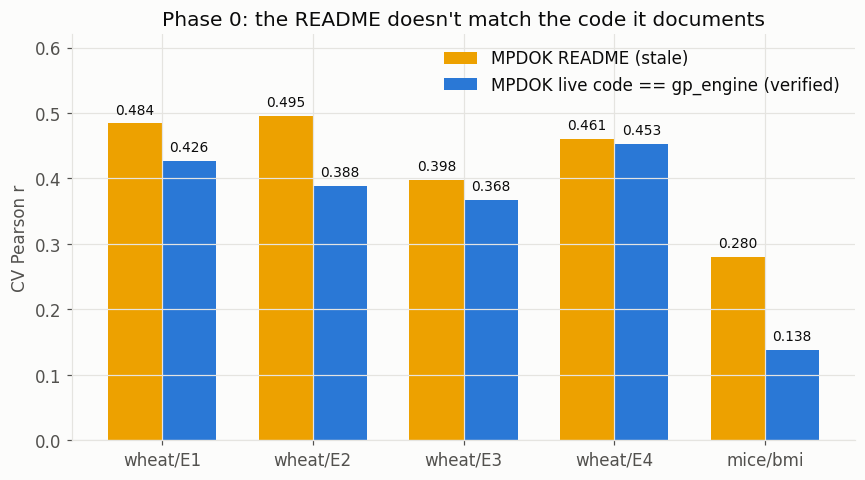

In [2]:
labels = ["wheat/E1", "wheat/E2", "wheat/E3", "wheat/E4", "mice/bmi"]
readme_claim = [0.484, 0.495, 0.398, 0.461, 0.280]
verified     = [0.4264, 0.3880, 0.3678, 0.4534, 0.1378]  # MPDOK live code == gp_engine

x = np.arange(len(labels))
w = 0.36
fig, ax = plt.subplots(figsize=(8, 4.5))
b1 = ax.bar(x - w/2, readme_claim, w, color=C_YELLOW, label="MPDOK README (stale)")
b2 = ax.bar(x + w/2, verified, w, color=C_BLUE,
           label="MPDOK live code == gp_engine (verified)")
bar_labels(ax, b1); bar_labels(ax, b2)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("CV Pearson r")
ax.set_title("Phase 0: the README doesn't match the code it documents")
ax.legend(frameon=False, loc="upper right")
ax.set_ylim(0, 0.62)
plt.tight_layout(); plt.show()

## 2. Calibration — the linear GRM can be confidently wrong; RKHS fixes it

Fraction of held-out predictions with a collapsed (near-zero) predictive
variance — a real FP32-envelope failure mode, not a rare edge case at scale.
The linear kernel hits it hard in two different datasets; the RKHS kernel
never does, in either. Sources: `RESULTS_PHASE1.md`, `RESULTS_PHASE2.md`,
`RESULTS_PHASE3.md`.

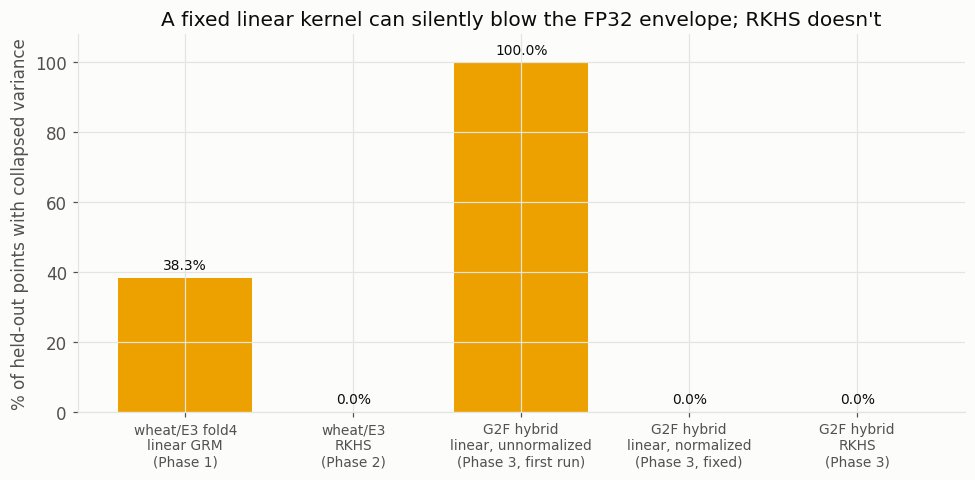

In [3]:
labels = ["wheat/E3 fold4\nlinear GRM\n(Phase 1)",
         "wheat/E3\nRKHS\n(Phase 2)",
         "G2F hybrid\nlinear, unnormalized\n(Phase 3, first run)",
         "G2F hybrid\nlinear, normalized\n(Phase 3, fixed)",
         "G2F hybrid\nRKHS\n(Phase 3)"]
pct_pathological = [46/120*100, 0/120*100, 4979/4979*100, 2/4979*100, 0/4979*100]
colors = [C_YELLOW, C_BLUE, C_YELLOW, C_BLUE, C_BLUE]

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(range(len(labels)), pct_pathological, color=colors)
for b, v in zip(bars, pct_pathological):
    ax.text(b.get_x() + b.get_width()/2, v + 1.5, f"{v:.1f}%",
           ha="center", va="bottom", fontsize=9, color=INK)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("% of held-out points with collapsed variance")
ax.set_title("A fixed linear kernel can silently blow the FP32 envelope; RKHS doesn't")
ax.set_ylim(0, 108)
plt.tight_layout(); plt.show()

## 3. Phase 2 — checked against the primary literature, not trusted on sight

The first RKHS-vs-linear comparison (vs. MPDOK's published GRM) showed a
suspiciously large gain. Located and read de los Campos, Gianola, Rosa,
Weigel & Crossa (2010, *Genetics Research* 92:295–308) directly — the exact
same 599-line, 4-environment wheat panel — and re-ran our own comparison
against the *right* baseline (a linear kernel built the same way, from the
same markers). The two independently-measured gains agree to within
~0.01–0.04 r on three of four environments. Source: `RESULTS_PHASE2.md`.

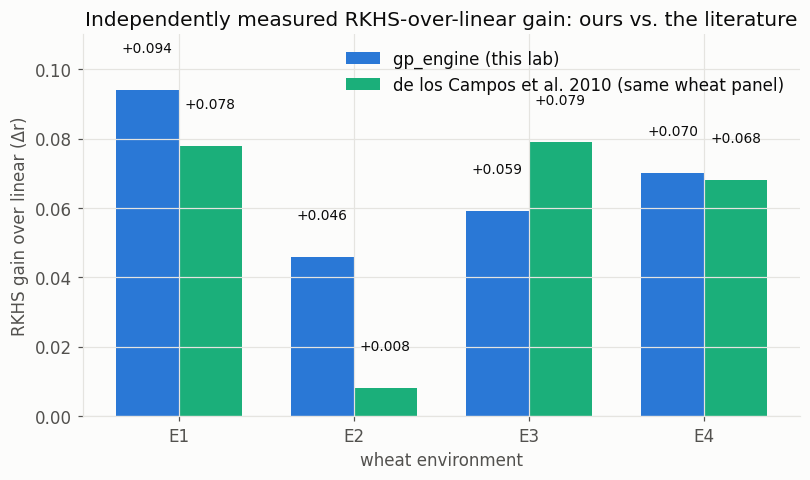

In [4]:
envs = ["E1", "E2", "E3", "E4"]
ours_gain  = [0.094, 0.046, 0.059, 0.070]   # gp_engine RKHS vs from-X linear
theirs_gain = [0.078, 0.008, 0.079, 0.068]  # de los Campos et al. 2010, Table A2

x = np.arange(len(envs)); w = 0.36
fig, ax = plt.subplots(figsize=(7.5, 4.5))
b1 = ax.bar(x - w/2, ours_gain, w, color=C_BLUE, label="gp_engine (this lab)")
b2 = ax.bar(x + w/2, theirs_gain, w, color=C_AQUA,
           label="de los Campos et al. 2010 (same wheat panel)")
bar_labels(ax, b1, fmt="+{:.3f}"); bar_labels(ax, b2, fmt="+{:.3f}")
ax.set_xticks(x); ax.set_xticklabels(envs)
ax.set_xlabel("wheat environment")
ax.set_ylabel("RKHS gain over linear (Δr)")
ax.set_title("Independently measured RKHS-over-linear gain: ours vs. the literature")
ax.legend(frameon=False, loc="upper right")
ax.set_ylim(0, 0.11)
plt.tight_layout(); plt.show()

## 4. Phase 3 vs Phase 4 — the honest cost of a genuinely new season

Phase 3 tested "known parents, unseen combination, same era" (random 5-fold
CV on 2014–2023 data). Phase 4 fetched the real, held-out **2024** G2F
season (downloaded *after* Phases 0–3 were already written) and tested
"unseen combination, unseen era" — the real shape of the competition's
task, scored on a marker-only model with no weather/soil/GxE covariates.
The accuracy drop is real and expected, not a regression. Source:
`RESULTS_PHASE3.md`, `RESULTS_PHASE4.md`.

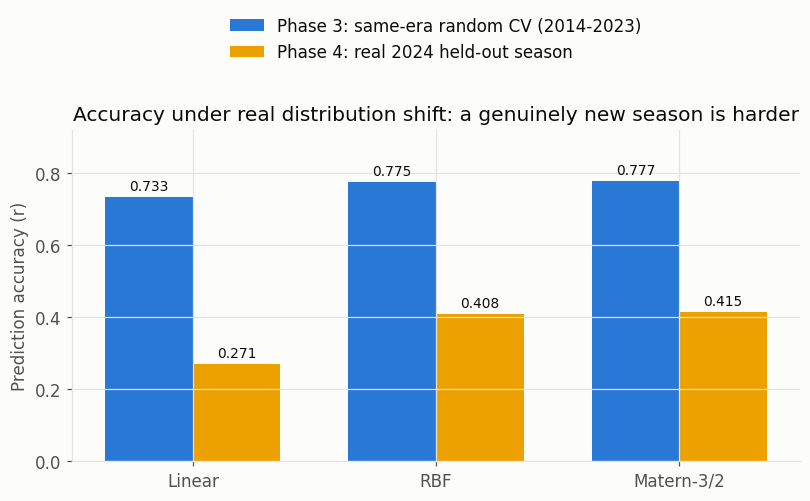

In [5]:
models = ["Linear", "RBF", "Matern-3/2"]
same_era   = [0.733, 0.775, 0.777]   # Phase 3: random CV, 2014-2023 only
real_2024  = [0.271, 0.408, 0.415]   # Phase 4: trained 2014-2023, predicted real 2024

x = np.arange(len(models)); w = 0.36
fig, ax = plt.subplots(figsize=(7.5, 4.8))
b1 = ax.bar(x - w/2, same_era, w, color=C_BLUE,
           label="Phase 3: same-era random CV (2014-2023)")
b2 = ax.bar(x + w/2, real_2024, w, color=C_YELLOW,
           label="Phase 4: real 2024 held-out season")
bar_labels(ax, b1); bar_labels(ax, b2)
ax.set_xticks(x); ax.set_xticklabels(models)
ax.set_ylabel("Prediction accuracy (r)")
ax.set_title("Accuracy under real distribution shift: a genuinely new season is harder")
ax.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.5, 1.16), ncol=1)
ax.set_ylim(0, 0.92)
plt.tight_layout(); plt.show()

## 5. The full span — best RKHS accuracy across every dataset in the lab

From a 599-line wheat trial to a 48,580-marker maize hybrid panel to a real
held-out future season — same engine, same `PrecomputedKernel` +
`marker_kernel.py` pipeline throughout. Source: `RESULTS_PHASE2.md`,
`RESULTS_PHASE3.md`, `RESULTS_PHASE4.md`.

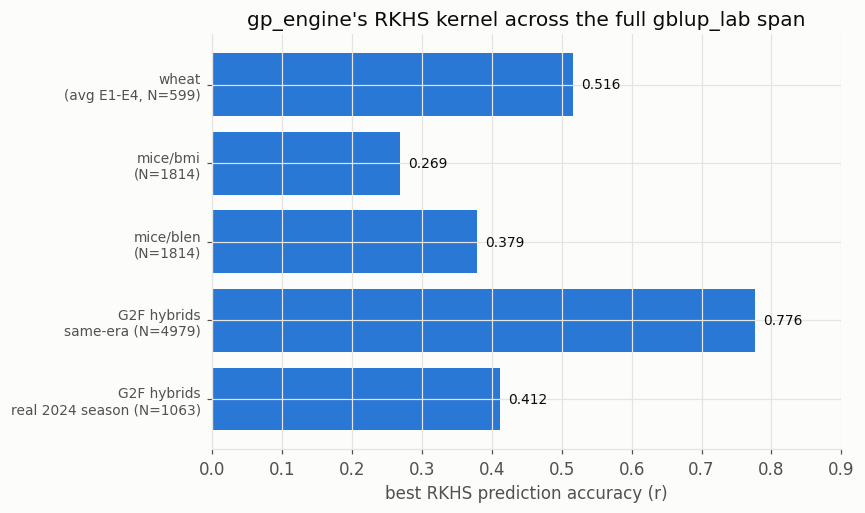

In [6]:
datasets = ["wheat\n(avg E1-E4, N=599)", "mice/bmi\n(N=1814)",
           "mice/blen\n(N=1814)", "G2F hybrids\nsame-era (N=4979)",
           "G2F hybrids\nreal 2024 season (N=1063)"]
best_r = [0.5162, 0.2689, 0.3788, 0.7763, 0.4116]

fig, ax = plt.subplots(figsize=(8, 4.8))
bars = ax.barh(range(len(datasets)), best_r, color=C_BLUE)
for b, v in zip(bars, best_r):
    ax.text(v + 0.012, b.get_y() + b.get_height()/2, f"{v:.3f}",
           va="center", fontsize=9, color=INK)
ax.set_yticks(range(len(datasets))); ax.set_yticklabels(datasets, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("best RKHS prediction accuracy (r)")
ax.set_title("gp_engine's RKHS kernel across the full gblup_lab span")
ax.set_xlim(0, 0.9)
plt.tight_layout(); plt.show()

---

**Reproduce:** `run_phase0.py` through `run_phase4.py`, from `gblup_lab/`,
inside conda `py314`. See `README.md` for the full command list and data
provenance for each phase.